# Lasso Regression

---
## Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = './processed'
OUT_DIR       = '../project/outputs/lasso_regression'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Config OK. Output directory: ../project/outputs/lasso_regression


---
## Load Pre-Processed Artefacts

In [ ]:
# Loading Scaled Data
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv',   index_col=0)
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv',  index_col=0)

# Regression targets
y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()

feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

X_train = X_train.fillna(0).astype('float64')
X_val   = X_val.fillna(0).astype('float64')
X_test  = X_test.fillna(0).astype('float64')

y_reg_train = y_reg_train.fillna(y_reg_train.mean()).astype('float64')
y_reg_val   = y_reg_val.fillna(y_reg_val.mean()).astype('float64')
y_reg_test  = y_reg_test.fillna(y_reg_test.mean()).astype('float64')

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')
print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')

Loaded splits:
  Train   64000 rows  49 features
  Val      8000 rows  49 features
  Test     8000 rows  49 features

Regression target  — mean=89.15, std=11.57


---
## Lasso Regression

In [ ]:
class LassoRegression:
    def __init__(self, lambda_=1.0, max_iter=1000, tol=1e-6, warm_start=False):
        self.lambda_    = lambda_
        self.max_iter   = max_iter
        self.tol        = tol
        self.warm_start = warm_start
        self.coef_      = None
        self.intercept_ = 0.0
        self.n_iter_    = 0

    @staticmethod
    def _soft_threshold(z, gamma):
        return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)

    def fit(self, X, y):
        X_ = np.asarray(X, dtype=float)
        y_ = np.asarray(y, dtype=float)
        n, p = X_.shape

        self.intercept_ = y_.mean()
        y_c = y_ - self.intercept_

        col_norms_sq = (X_ ** 2).sum(axis=0)
        col_norms_sq = np.where(col_norms_sq == 0, 1.0, col_norms_sq)

        # Warm start: reuse previous coef_ if available, else zero-init
        if not (self.warm_start and self.coef_ is not None and len(self.coef_) == p):
            self.coef_ = np.zeros(p)

        # Maintain residual vector to avoid recomputing X @ coef each inner step
        residual = y_c - X_ @ self.coef_

        for iteration in range(self.max_iter):
            beta_old = self.coef_.copy()

            for j in range(p):
                old_j = self.coef_[j]
                r_j   = residual + X_[:, j] * old_j        # cheap: add back column j
                z_j   = X_[:, j] @ r_j / col_norms_sq[j]
                self.coef_[j] = self._soft_threshold(z_j, self.lambda_ / col_norms_sq[j])
                residual = r_j - X_[:, j] * self.coef_[j]  # update residual in place

            self.intercept_ = y_.mean() - X_.mean(axis=0) @ self.coef_

            if np.max(np.abs(self.coef_ - beta_old)) < self.tol:
                self.n_iter_ = iteration + 1
                break
        else:
            self.n_iter_ = self.max_iter

        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.coef_ + self.intercept_

    @property
    def n_nonzero_(self):
        return int(np.sum(self.coef_ != 0))


# --- Validation block ---
X_train_np = np.asarray(X_train, dtype=float)
X_val_np   = np.asarray(X_val,   dtype=float)
y_train_np = np.asarray(y_reg_train, dtype=float)
y_val_np   = np.asarray(y_reg_val,   dtype=float)

test_lambda = 0.01
scratch = LassoRegression(
    lambda_=test_lambda * len(X_train_np),
    max_iter=2000,
    tol=1e-6
).fit(X_train_np, y_train_np)

scratch_rmse = np.sqrt(mean_squared_error(y_val_np, scratch.predict(X_val_np)))
print(f'Lasso  Val RMSE : {scratch_rmse:.6f}  (non-zero coefs: {scratch.n_nonzero_})')
print(f'Iterations      : {scratch.n_iter_}')

Lasso  Val RMSE : 10.512347  (non-zero coefs: 32)
Iterations      : 461


---
## Regression Task — Predict `exam_score`

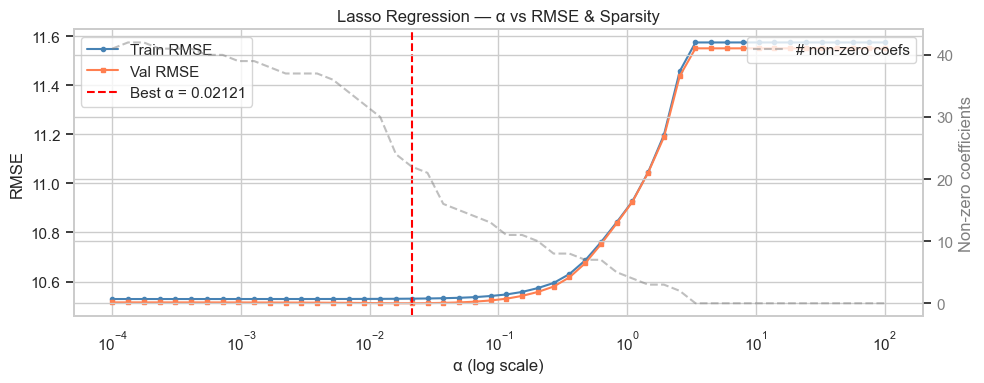

Best α: 0.02121  val RMSE=10.5115  non-zero=22


In [ ]:
n_train = len(X_train)
alphas  = np.logspace(-4, 2, 50)

train_rmses, val_rmses, n_nonzeros = [], [], []

for alpha in alphas:
    m = LassoRegression(lambda_=alpha * n_train, max_iter=2000)
    m.fit(X_train, y_reg_train)
    train_rmses.append(np.sqrt(mean_squared_error(y_reg_train, m.predict(X_train))))
    val_rmses.append(np.sqrt(mean_squared_error(y_reg_val,     m.predict(X_val))))
    n_nonzeros.append(m.n_nonzero_)

best_alpha_idx = np.argmin(val_rmses)
best_alpha_reg = alphas[best_alpha_idx]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.semilogx(alphas, train_rmses, 'o-', markersize=3, label='Train RMSE', color='steelblue')
ax1.semilogx(alphas, val_rmses,   's-', markersize=3, label='Val RMSE',   color='coral')
ax1.axvline(best_alpha_reg, color='red', linestyle='--',
            label=f'Best α = {best_alpha_reg:.5f}')
ax1.set_xlabel('α (log scale)')
ax1.set_ylabel('RMSE')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.semilogx(alphas, n_nonzeros, '--', color='gray', alpha=0.5, label='# non-zero coefs')
ax2.set_ylabel('Non-zero coefficients', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.legend(loc='upper right')

plt.title('Lasso Regression — α vs RMSE & Sparsity')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_alpha_vs_rmse.png', dpi=150)
plt.show()
print(f'Best α: {best_alpha_reg:.5f}  val RMSE={val_rmses[best_alpha_idx]:.4f}  non-zero={n_nonzeros[best_alpha_idx]}')

### Coefficient Regularisation Path (Lasso)

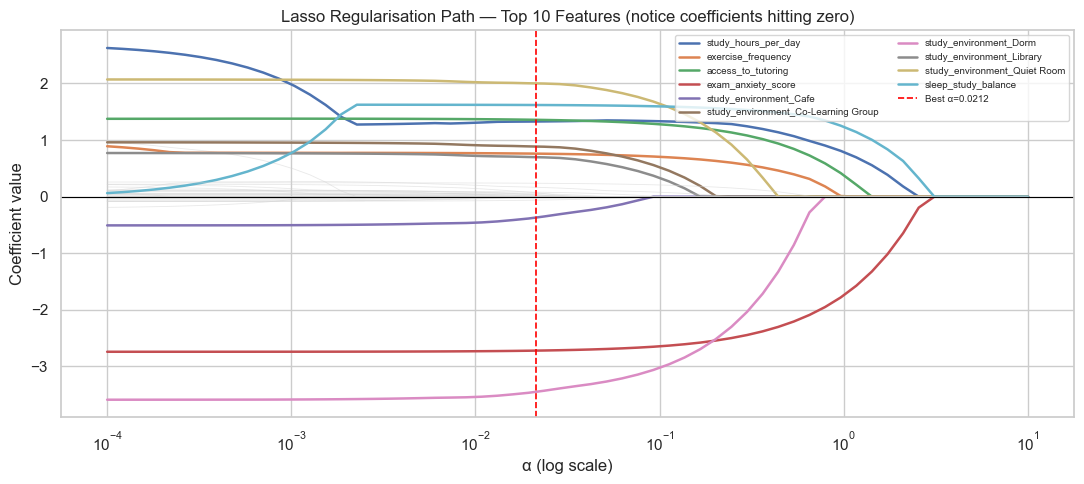

In [ ]:
path_alphas = np.logspace(-4, 1, 60)
coef_paths  = []

for alpha in path_alphas:
    m = LassoRegression(lambda_=alpha * n_train, max_iter=2000)
    m.fit(X_train, y_reg_train)
    coef_paths.append(m.coef_.copy())

coef_paths = np.array(coef_paths)   # (n_alphas, n_features)

# Identify top-10 features by absolute coefficient at the best alpha
best_model_path = LassoRegression(lambda_=best_alpha_reg * n_train, max_iter=2000)
best_model_path.fit(X_train, y_reg_train)
top10_idx = np.argsort(np.abs(best_model_path.coef_))[::-1][:10]

plt.figure(figsize=(11, 5))
for i in range(len(feature_names)):
    if i in top10_idx:
        plt.semilogx(path_alphas, coef_paths[:, i],
                     lw=1.8, label=feature_names[i])
    else:
        plt.semilogx(path_alphas, coef_paths[:, i],
                     color='lightgray', lw=0.6, alpha=0.5)
plt.axvline(best_alpha_reg, color='red', linestyle='--', lw=1.2, label=f'Best α={best_alpha_reg:.4f}')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('α (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Regularisation Path — Top 10 Features (notice coefficients hitting zero)')
plt.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_regularisation_path.png', dpi=150)
plt.show()

In [ ]:
X_trainval     = pd.concat([X_train, X_val])
y_reg_trainval = pd.concat([y_reg_train, y_reg_val])
n_trainval     = len(X_trainval)

best_lasso_reg = LassoRegression(lambda_=best_alpha_reg * n_trainval, max_iter=3000)
best_lasso_reg.fit(X_trainval, y_reg_trainval)

y_reg_pred = best_lasso_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 40)
print(f'  Best α       : {best_alpha_reg:.5f}')
print(f'  Non-zero coef: {best_lasso_reg.n_nonzero_} / {X_train.shape[1]}')
print(f'  RMSE         : {rmse:.3f}')
print(f'  MAE          : {mae:.3f}')
print(f'  R²           : {r2:.4f}')
print('─' * 40)

────────────────────────────────────────
  Best α       : 0.02121
  Non-zero coef: 21 / 49
  RMSE         : 10.676
  MAE          : 8.777
  R²           : 0.1768
────────────────────────────────────────


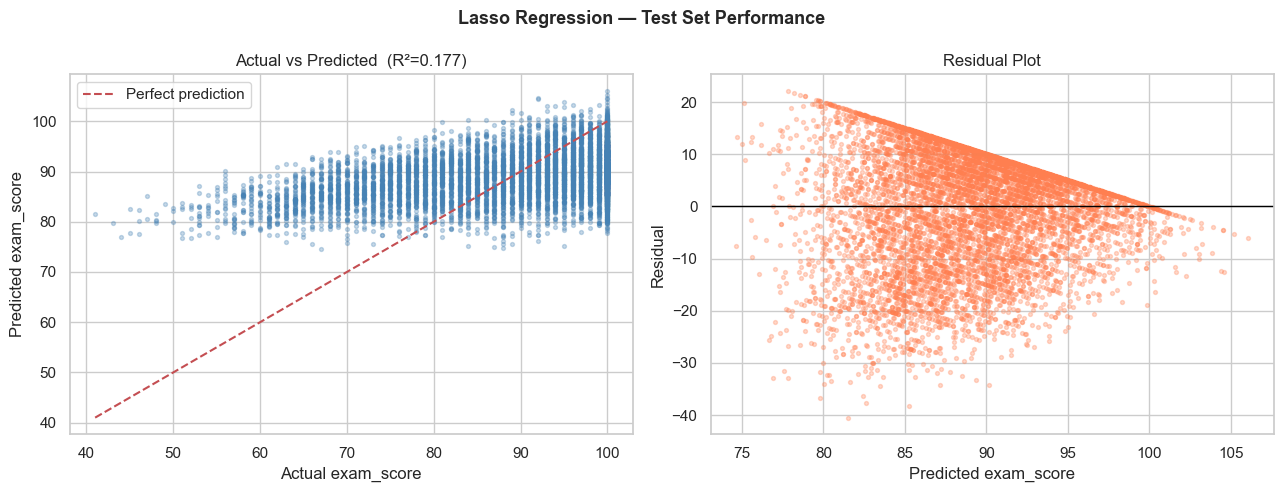

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

residuals = y_reg_test.values - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('Lasso Regression — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

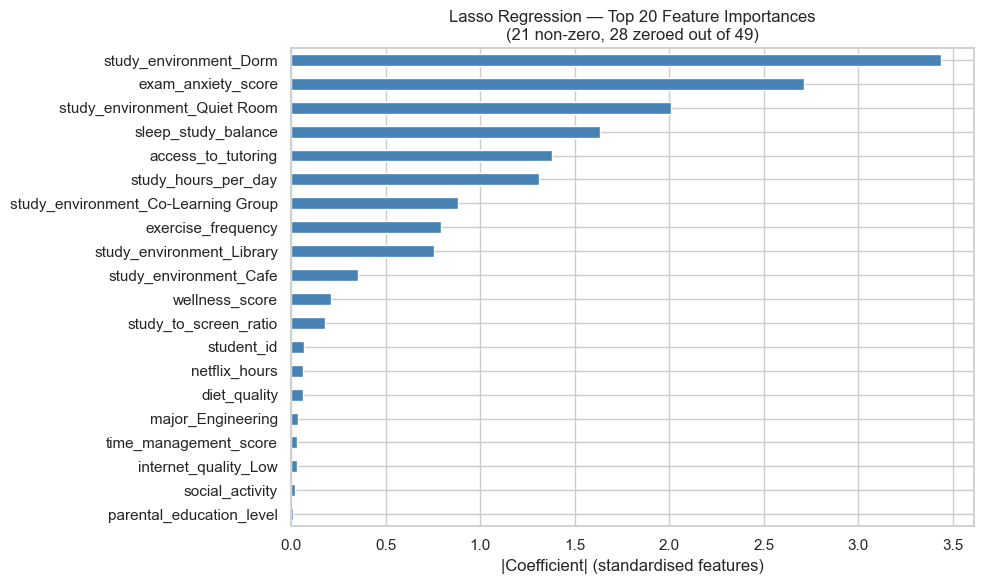

In [ ]:
importances_reg = pd.Series(np.abs(best_lasso_reg.coef_), index=feature_names)
top20_reg       = importances_reg.sort_values(ascending=False).head(20)
n_zero          = (best_lasso_reg.coef_ == 0).sum()

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'lightgray' for v in top20_reg]
top20_reg.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.xlabel('|Coefficient| (standardised features)')
plt.title(f'Lasso Regression — Top 20 Feature Importances\n'
          f'({best_lasso_reg.n_nonzero_} non-zero, {n_zero} zeroed out of {X_train.shape[1]})')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

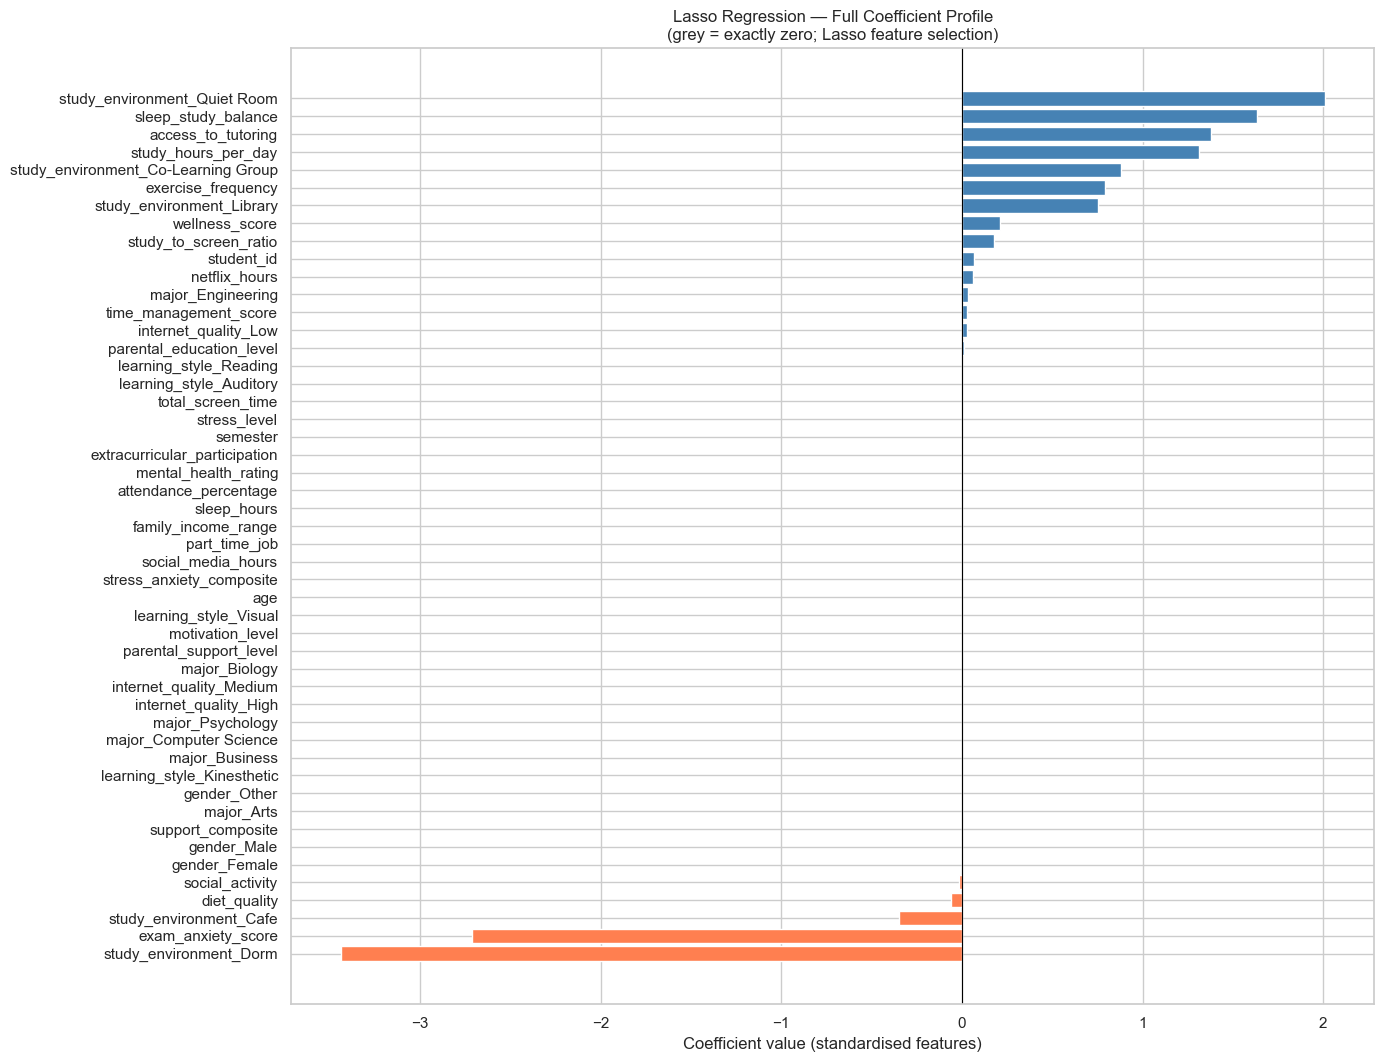

In [ ]:
all_coefs = pd.Series(best_lasso_reg.coef_, index=feature_names).sort_values()

colors = ['coral' if v < 0 else ('steelblue' if v > 0 else 'lightgray')
          for v in all_coefs]

plt.figure(figsize=(14, max(5, len(feature_names) * 0.22)))
plt.barh(all_coefs.index, all_coefs.values, color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient value (standardised features)')
plt.title('Lasso Regression — Full Coefficient Profile\n(grey = exactly zero; Lasso feature selection)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_full_coef_profile.png', dpi=150, bbox_inches='tight')
plt.show()

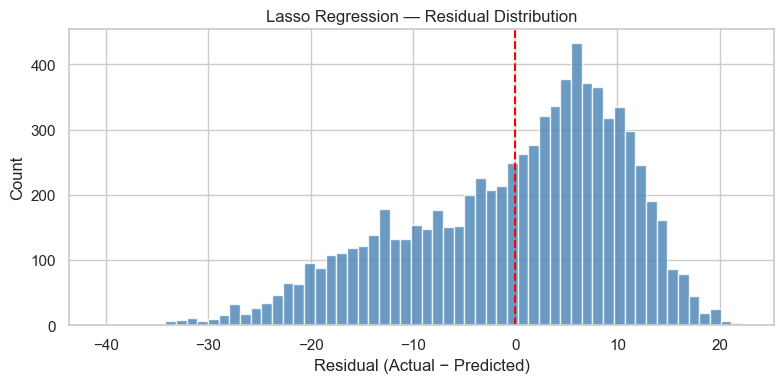

Residual mean : -0.0489
Residual std  : 10.6757


In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Count')
plt.title('Lasso Regression — Residual Distribution')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_residual_distribution.png', dpi=150)
plt.show()
print(f'Residual mean : {residuals.mean():.4f}')
print(f'Residual std  : {residuals.std():.4f}')

In [ ]:
joblib.dump(best_lasso_reg, f'{OUT_DIR}/models/lasso_reg.joblib')
print(f'Lasso regression model saved  (α={best_alpha_reg:.5f}, non-zero={best_lasso_reg.n_nonzero_})')

Lasso regression model saved  (α=0.02121, non-zero=21)


---
## Results Summary

In [ ]:
summary = pd.DataFrame([
    {
        'Task':         'Regression (exam_score)',
        'Best α':       f'{best_alpha_reg:.5f}',
        'Non-zero':     f'{best_lasso_reg.n_nonzero_} / {X_train.shape[1]}',
        'Test RMSE':    f'{rmse:.3f}',
        'Test MAE':     f'{mae:.3f}',
        'Test R²':      f'{r2:.4f}',
        'Test Acc':     '—',
        'Test F1':      '—',
        'Test AUC':     '—',
    }
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best α,Non-zero,Test RMSE,Test MAE,Test R²,Test Acc,Test F1,Test AUC
0,Regression (exam_score),0.02121,21 / 49,10.676,8.777,0.1768,—,—,—



All figures saved to: ../project/outputs/lasso_regression/figures/
All models saved to:  ../project/outputs/lasso_regression/models/
